In [1]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

In [2]:
import os
import pandas as pd
from PIL import Image, UnidentifiedImageError

In [3]:
# Paths
json_path = r"C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_photos\photos.json"
image_dir = r"C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_photos\photos"

In [4]:
# Load metadata
df = pd.read_json(json_path, lines=True)

# Construct full image paths
df["file_path"] = df["photo_id"].apply(lambda x: os.path.join(image_dir, f"{x}.jpg"))

# Filter only existing images
df = df[df["file_path"].apply(os.path.exists)]

# Filter out images that can't be opened (invalid images)
def is_valid_image(img_path):
    try:
        img = Image.open(img_path)
        img.verify()  # Verifies if the image is valid
        return True
    except (UnidentifiedImageError, IOError):
        return False

# Filter out only valid images
df_valid_images = df[df["file_path"].apply(is_valid_image)]

# Sample 30,000 images
sample_df = df_valid_images.sample(n=10000, random_state=42)

# Print the number of valid images
print(f"Total valid images: {len(sample_df)}")

Total valid images: 10000


In [5]:
from torchvision import transforms
from diffusers import DDIMPipeline
from matplotlib import pyplot as plt
import numpy as np
from sklearn.metrics import pairwise_distances_argmin_min
from scipy.linalg import sqrtm
import torch.nn.functional as F

In [6]:
# Preprocess images for model
def preprocess_images(df):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),  # Resize to fit the model input size
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # Normalization
    ])
    
    images = []
    for img_path in df['file_path']:
        img = Image.open(img_path).convert("RGB")
        img = transform(img)
        images.append(img)
    
    return torch.stack(images)

# Preprocessed images
images = preprocess_images(sample_df)

In [7]:
from diffusers import StableDiffusionPipeline, DDIMScheduler

# Load the model using float32
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float32)  
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)  
pipe.to("cpu")  

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.32.2",
  "_name_or_path": "runwayml/stable-diffusion-v1-5",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "DDIMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

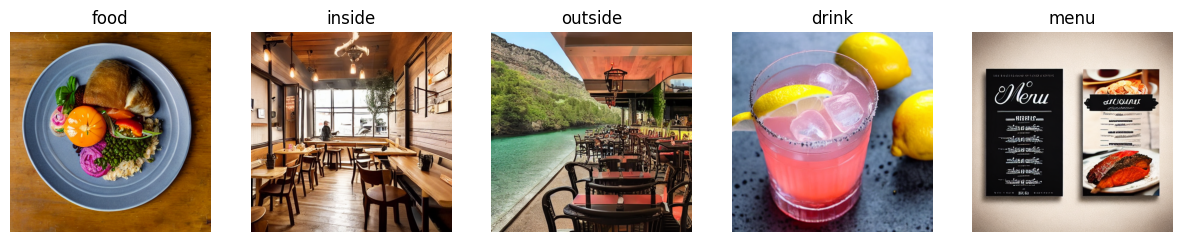

In [8]:
# Define prompts for each class
labels = {
    "food": "A delicious gourmet meal on a fancy plate",
    "inside": "A cozy cafe with warm lighting and wooden furniture",
    "outside": "A restaurant with outdoor seating and a scenic view",
    "drink": "A refreshing cocktail with ice and lemon in a glass",
    "menu": "A restaurant menu with elegant typography and images of food"
}

# Generate images
generated_images = []
for label, prompt in labels.items():
    image = pipe(prompt, num_inference_steps=50).images[0]
    generated_images.append((label, image))

# Display images in Jupyter Notebook
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for ax, (label, img) in zip(axes, generated_images):
    ax.imshow(img)
    ax.set_title(label)
    ax.axis("off")

plt.show()

In [10]:
from scipy.stats import entropy
from torchvision.models import inception_v3

# Load the InceptionV3 model
inception_model = inception_v3(pretrained=True, transform_input=False).eval()

# Function to calculate Inception Score
def inception_score(images, splits=10):
    N = len(images)
    split_scores = []

    # Split images into parts for calculating IS
    for k in range(splits):
        part = images[k * N // splits:(k + 1) * N // splits]
        preds = torch.stack([F.softmax(inception_model(img.unsqueeze(0)), dim=1).cpu().detach() for img in part])
        split_scores.append(preds)

    # Calculate Inception Score
    mean_score = np.mean([entropy(pred.numpy()) for pred in split_scores])
    return mean_score

# Assuming you have your images in a tensor format:
# images is a tensor of shape (N, 3, 128, 128)
score = inception_score(images)
print(f"Inception Score: {score}")

C:\Users\JISNA\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\JISNA\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Inception Score: 1.9449671506881714


In [11]:
from scipy.linalg import sqrtm

# Function to calculate FID
def calculate_fid(images, generated_images):
    # Extract features for real images and generated images
    real_features = get_inception_features(images)
    generated_features = get_inception_features(generated_images)

    # Calculate the mean and covariance of real and generated features
    mu_real, sigma_real = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu_gen, sigma_gen = generated_features.mean(axis=0), np.cov(generated_features, rowvar=False)

    # Compute FID
    diff = mu_real - mu_gen
    covmean = sqrtm(sigma_real @ sigma_gen)
    fid = np.sum(diff**2) + np.trace(sigma_real + sigma_gen - 2 * covmean)
    return fid

# Function to get Inception features
def get_inception_features(images):
    inception_model.eval()
    with torch.no_grad():
        features = []
        for img in images:
            # Make sure to extract the image tensor from the tuple and apply unsqueeze
            img_tensor = img[0] if isinstance(img, tuple) else img  # In case the image is already a tensor
            feature = inception_model(img_tensor.unsqueeze(0))  # Unsqueeze to add batch dimension
            features.append(feature.detach().cpu().numpy())
    return np.array(features)
